# Ejercicio Regression Tree
Son datos de temperaturas tomados de la ciudad de Seattle. El objetivo es intentar predecir lo mejor posible la máxima temperatura (columna `actual`) que alcanzaremos al día siguiente. Para ello contaremos con temperaturas de los dos días anteriores, históricos de máximas temperaturas y un amigo bastante chapas que te da su predicción del tiempo cada día.

**Resumen de datos**:
* year: 2016 for all data points
* month: number for month of the year
* day: number for day of the year
* week: day of the week as a character string
* temp_2: max temperature 2 days prior
* temp_1: max temperature 1 day prior
* average: historical average max temperature
* actual: max temperature measurement
* friend: your friend’s prediction, a random number between 20 below the average and 20 above the average

In [185]:
import pandas as pd
import seaborn as sns
import os
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from sklearn.model_selection import GridSearchCV
from sklearn.tree import plot_tree
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, OneHotEncoder, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

In [113]:
# to make this notebook's output stable across runs
np.random.seed(42)

# To plot pretty figures
# %matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

# Where to save the figures
PROJECT_ROOT_DIR = "."
CHAPTER_ID = "decision_trees"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", CHAPTER_ID)
os.makedirs(IMAGES_PATH, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

### 1. Importa el csv "temps.csv"

In [114]:
df_seattle = pd.read_csv("data/temps.csv")
df_seattle

,year,month,day,week,temp_2,temp_1,average,actual,forecast_noaa,forecast_acc,forecast_under,friend
0,2016,1,1,Fri,45,45,45.6,45,43,50,44,29
1,2016,1,2,Sat,44,45,45.7,44,41,50,44,61
2,2016,1,3,Sun,45,44,45.8,41,43,46,47,56
3,2016,1,4,Mon,44,41,45.9,40,44,48,46,53
4,2016,1,5,Tues,41,40,46.0,44,46,46,46,41
...,...,...,...,...,...,...,...,...,...,...,...,...
343,2016,12,27,Tues,42,42,45.2,47,41,50,47,47
344,2016,12,28,Wed,42,47,45.3,48,41,49,44,58
345,2016,12,29,Thurs,47,48,45.3,48,43,50,45,65
346,2016,12,30,Fri,48,48,45.4,57,44,46,44,42


### 2. Realiza un análisis exploratorio junto con un Feature Engineering

In [115]:
df_seattle.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 348 entries, 0 to 347
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   year            348 non-null    int64  
 1   month           348 non-null    int64  
 2   day             348 non-null    int64  
 3   week            348 non-null    object 
 4   temp_2          348 non-null    int64  
 5   temp_1          348 non-null    int64  
 6   average         348 non-null    float64
 7   actual          348 non-null    int64  
 8   forecast_noaa   348 non-null    int64  
 9   forecast_acc    348 non-null    int64  
 10  forecast_under  348 non-null    int64  
 11  friend          348 non-null    int64  
dtypes: float64(1), int64(10), object(1)
memory usage: 32.8+ KB


In [116]:
df_seattle.describe()

,year,month,day,temp_2,temp_1,average,actual,forecast_noaa,forecast_acc,forecast_under,friend
count,348.0,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000
mean,2016.0,6.477011,15.514368,62.652299,62.701149,59.760632,62.543103,57.238506,62.373563,59.772989,60.034483
std,0.0,3.498380,8.772982,12.165398,12.120542,10.527306,11.794146,10.605746,10.549381,10.705256,15.626179
min,2016.0,1.000000,1.000000,35.000000,35.000000,45.100000,35.000000,41.000000,46.000000,44.000000,28.000000
25%,2016.0,3.000000,8.000000,54.000000,54.000000,49.975000,54.000000,48.000000,53.000000,50.000000,47.750000
50%,2016.0,6.000000,15.000000,62.500000,62.500000,58.200000,62.500000,56.000000,61.000000,58.000000,60.000000
75%,2016.0,10.000000,23.000000,71.000000,71.000000,69.025000,71.000000,66.000000,72.000000,69.000000,71.000000
max,2016.0,12.000000,31.000000,117.000000,117.000000,77.400000,92.000000,77.000000,82.000000,79.000000,95.000000


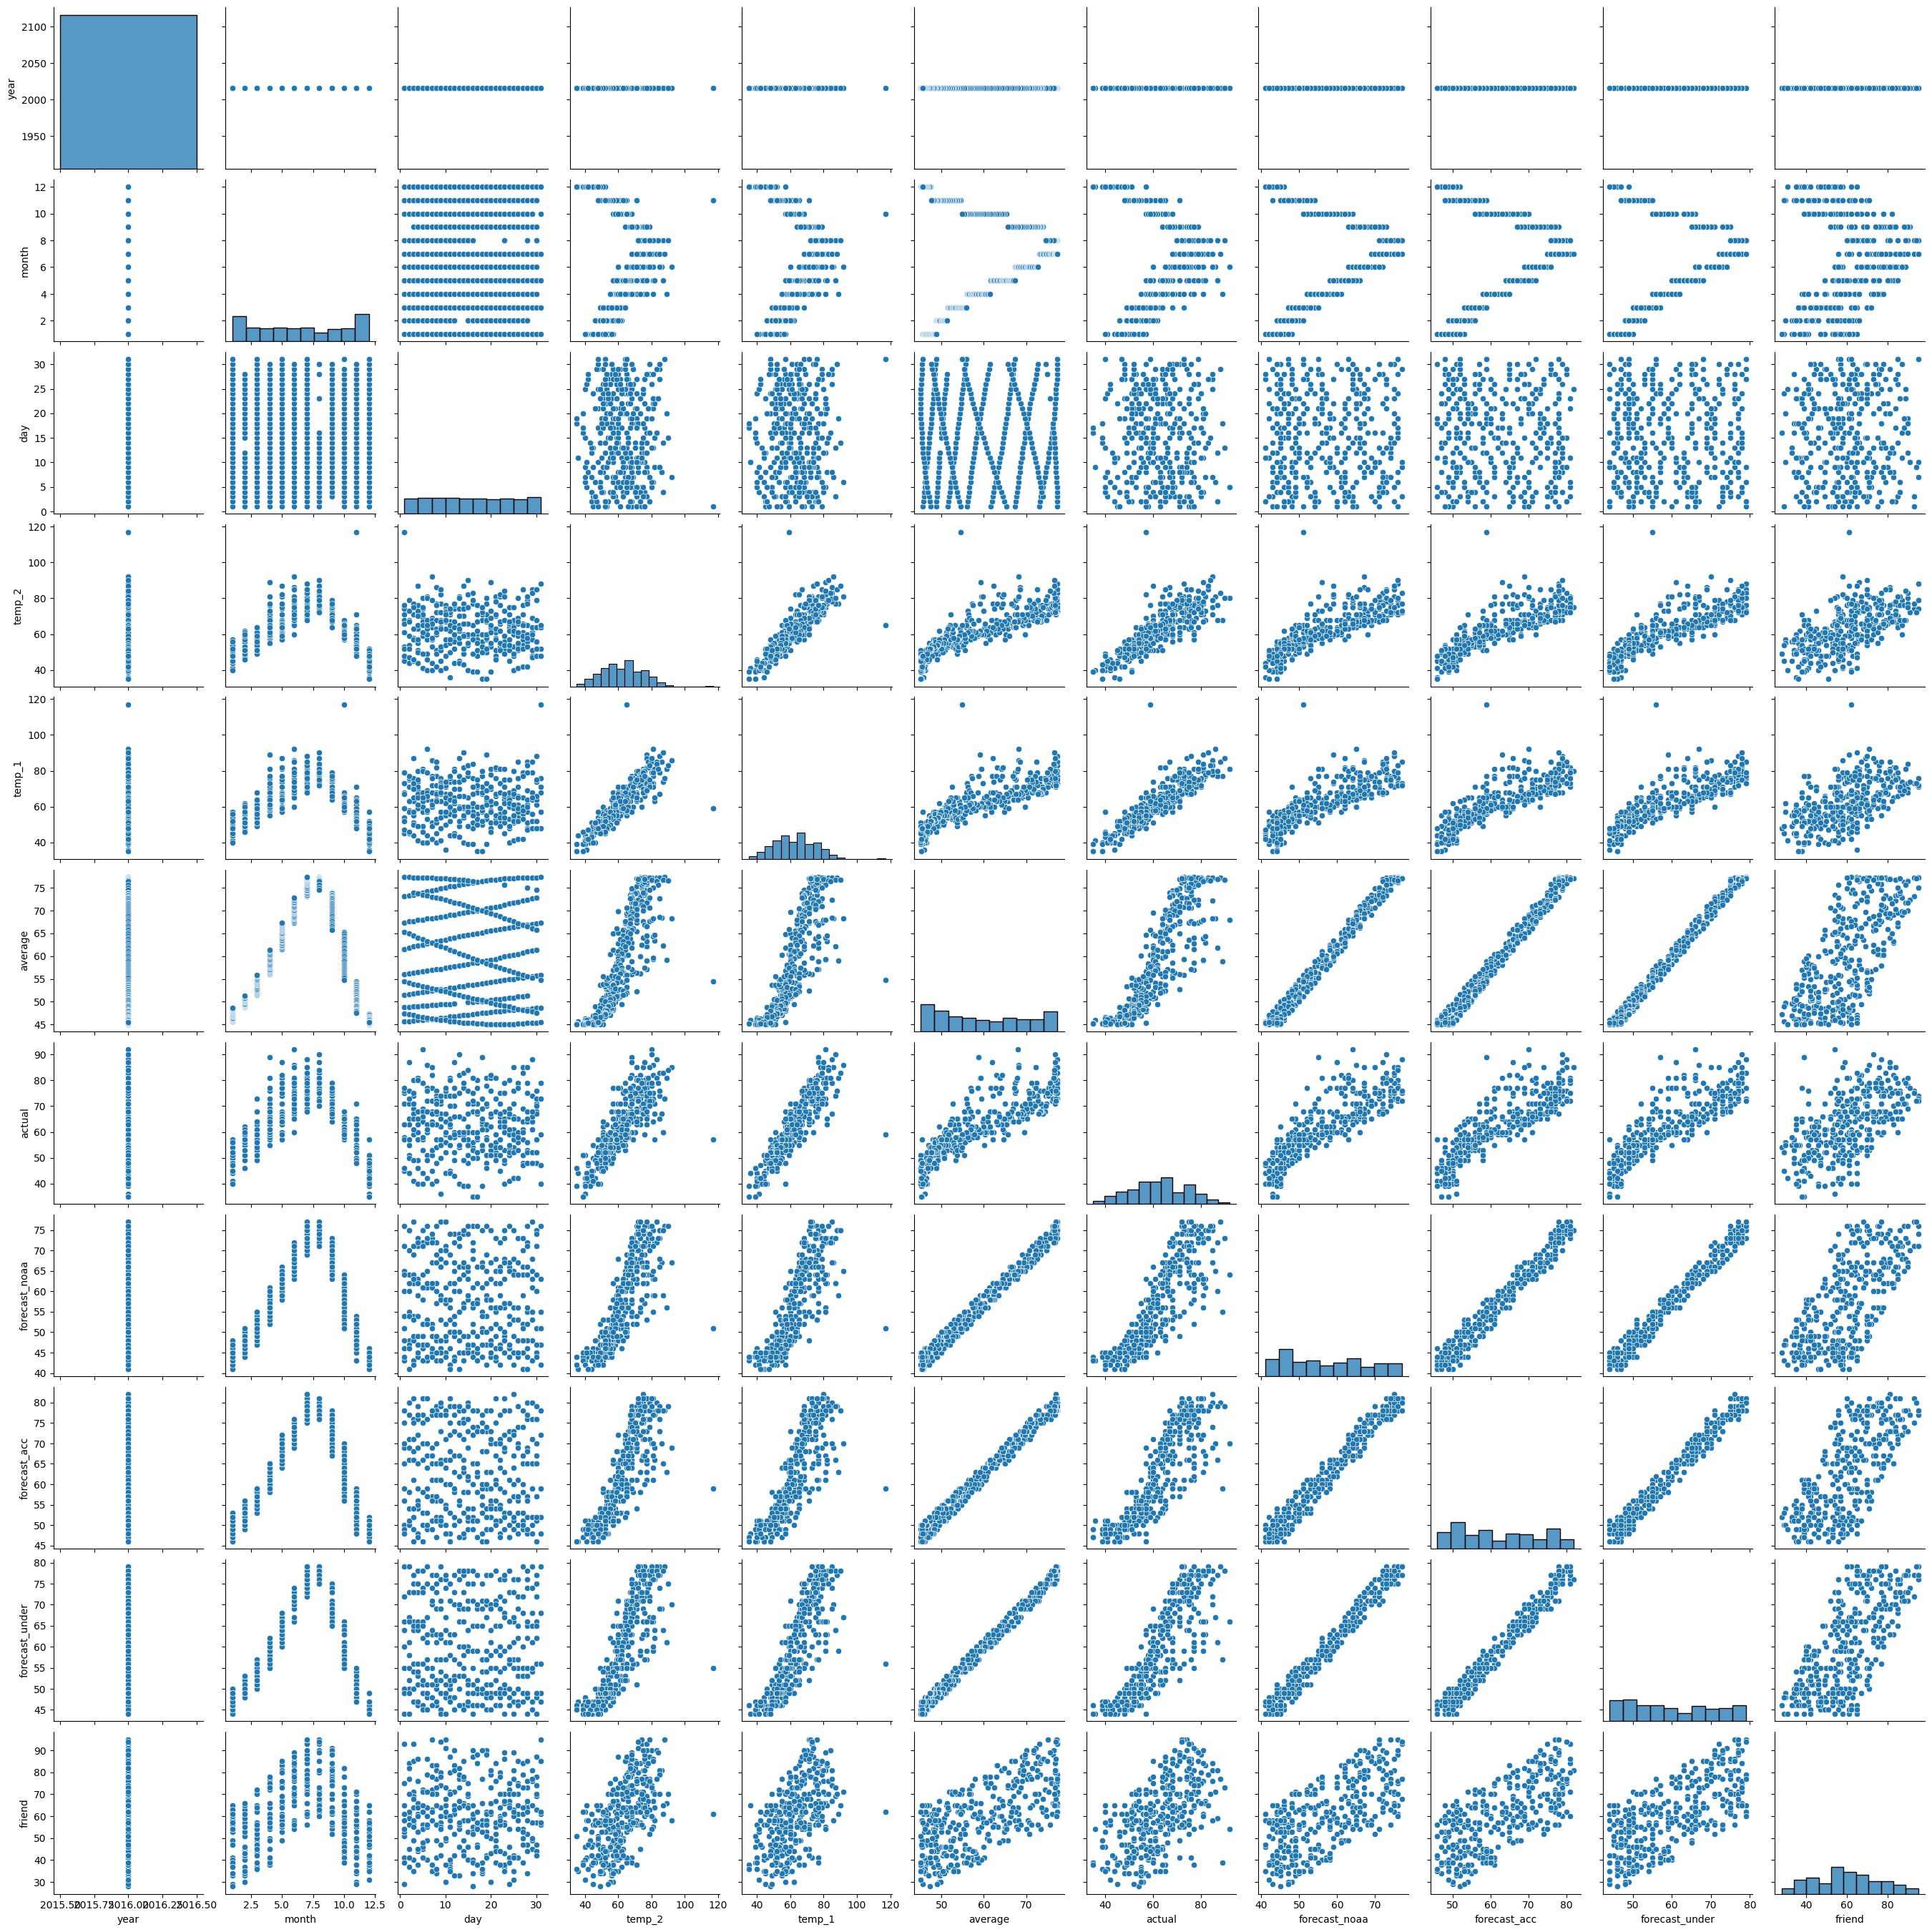

In [5]:
sns.pairplot(df_seattle)

In [ ]:
df_seattle.drop(columns="year").corr(numeric_only=True)

,month,day,temp_2,temp_1,average,actual,forecast_noaa,forecast_acc,forecast_under,friend
month,1.000000,-0.000412,0.047651,0.032664,0.120806,0.004529,0.131141,0.127436,0.119786,0.048145
day,-0.000412,1.000000,-0.046194,-0.000691,-0.021136,-0.021675,-0.021393,-0.030605,-0.013727,0.024592
temp_2,0.047651,-0.046194,1.000000,0.857800,0.821560,0.805835,0.813134,0.817374,0.819576,0.583758
temp_1,0.032664,-0.000691,0.857800,1.000000,0.819328,0.877880,0.810672,0.815162,0.815943,0.541282
average,0.120806,-0.021136,0.821560,0.819328,1.000000,0.848365,0.990340,0.990705,0.994373,0.689278
actual,0.004529,-0.021675,0.805835,0.877880,0.848365,1.000000,0.838639,0.842135,0.838946,0.569145
forecast_noaa,0.131141,-0.021393,0.813134,0.810672,0.990340,0.838639,1.000000,0.979863,0.985670,0.669221
forecast_acc,0.127436,-0.030605,0.817374,0.815162,0.990705,0.842135,0.979863,1.000000,0.983910,0.696054
forecast_under,0.119786,-0.013727,0.819576,0.815943,0.994373,0.838946,0.985670,0.983910,1.000000,0.691177
friend,0.048145,0.024592,0.583758,0.541282,0.689278,0.569145,0.669221,0.696054,0.691177,1.000000


<Figure size 1100x400 with 0 Axes>

<Axes: >

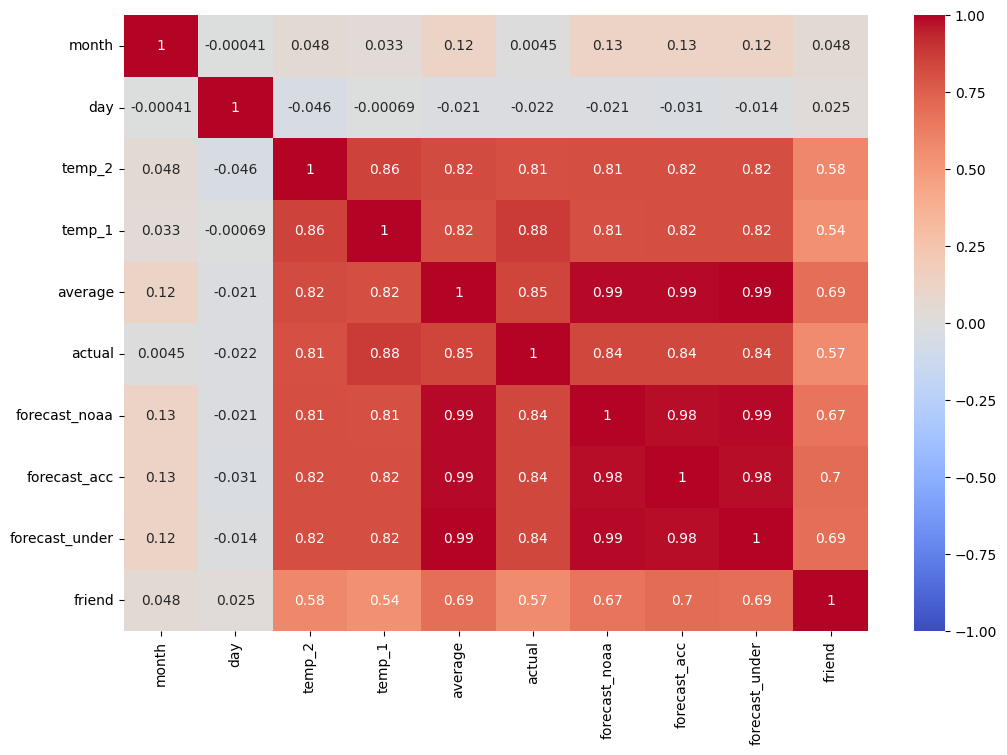

In [20]:
plt.figure(figsize=(12, 8))
sns.heatmap(df_seattle.drop(columns="year").corr(numeric_only=True), annot=True, vmin= -1, cmap="coolwarm")

### 3. Selecciona variables y divide en train y test

In [173]:
X = df_seattle.drop(columns=["actual", "year", "week"])
y = df_seattle["actual"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=11)

In [119]:
X

,month,day,temp_2,temp_1,average,forecast_noaa,forecast_acc,forecast_under,friend
0,1,1,45,45,45.6,43,50,44,29
1,1,2,44,45,45.7,41,50,44,61
2,1,3,45,44,45.8,43,46,47,56
3,1,4,44,41,45.9,44,48,46,53
4,1,5,41,40,46.0,46,46,46,41
...,...,...,...,...,...,...,...,...,...
343,12,27,42,42,45.2,41,50,47,47
344,12,28,42,47,45.3,41,49,44,58
345,12,29,47,48,45.3,43,50,45,65
346,12,30,48,48,45.4,44,46,44,42


In [170]:
y

0      45
1      44
2      41
3      40
4      44
       ..
343    47
344    48
345    48
346    57
347    40
Name: actual, Length: 348, dtype: int64

### 4. Entrena el modelo


#### Modelo de regresión lineal

In [172]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

pred = linear_model.predict(X_test)

print("MAE: ", mean_absolute_error(y_test, pred))
print("RMSE: ", root_mean_squared_error(y_test, pred))
print("MAPE: ", mean_absolute_percentage_error(y_test, pred))
print("R2: ", r2_score(y_test, pred))

MAE:  3.5970042954127206
RMSE:  4.634402907280088
MAPE:  0.055215205267104946
R2:  0.8484297479832098


#### Modelo de regresión polinómica

In [122]:
poly_feats = PolynomialFeatures(degree = 2)
poly_feats.fit(X)
X_poly = poly_feats.transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_poly,y, test_size = 0.2, random_state=42)

boston_model_poly = LinearRegression()
boston_model_poly.fit(X_train, y_train)

pred_poly = boston_model_poly.predict(X_test)

print("MAE: ", mean_absolute_error(y_test, pred_poly))
print("RMSE: ", root_mean_squared_error(y_test, pred_poly))
print("MAPE: ", mean_absolute_percentage_error(y_test, pred_poly))
print("R2: ", r2_score(y_test, pred_poly))

MAE:  4.384121055919135
RMSE:  5.844727239974836
MAPE:  0.06922854659115796
R2:  0.7556891706012913


#### Ridge

In [123]:
scaler = StandardScaler()
scaler.fit(X_train)             

X_train_st = scaler.transform(X_train)
X_test_st = scaler.transform(X_test)

In [124]:
ridge = Ridge(alpha=1)
ridge.fit(X_train_st, y_train)

pred_r = ridge.predict(X_test_st)

print("MAE: ", mean_absolute_error(y_test, pred_r))
print("RMSE: ", root_mean_squared_error(y_test, pred_r))
print("MAPE: ", mean_absolute_percentage_error(y_test, pred_r))
print("R2: ", r2_score(y_test, pred_r))

MAE:  3.4623473546732635
RMSE:  4.608161100832456
MAPE:  0.05506577169851768
R2:  0.8481308618582306


#### Lasso

In [125]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_st, y_train)

pred_l = lasso.predict(X_test_st)

print("MAE: ", mean_absolute_error(y_test, pred_l))
print("RMSE: ", root_mean_squared_error(y_test, pred_l))
print("MAPE: ", mean_absolute_percentage_error(y_test, pred_l))
print("R2: ", r2_score(y_test, pred_l))

MAE:  3.4855761363942666
RMSE:  4.813538797730047
MAPE:  0.05551543255690807
R2:  0.8342921149268813


#### Decission Trees

In [174]:
tree_clf = DecisionTreeRegressor(max_depth=6, random_state=42)
tree_clf.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,6
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [175]:
pred_t = tree_clf.predict(X_test)

print("MAE: ", mean_absolute_error(y_test, pred_t))
print("RMSE: ", root_mean_squared_error(y_test, pred_t))
print("MAPE: ", mean_absolute_percentage_error(y_test, pred_t))
print("R2: ", r2_score(y_test, pred_t))

MAE:  3.6934595034595046
RMSE:  4.803711202536344
MAPE:  0.056668073071459386
R2:  0.837152844652836


### 5. Evaluación de tu modelo
Calcula el coeficiente de determinación. 

Calcula el MAE, MAPE, MSE y RMSE.

In [176]:
print("MAE: ", mean_absolute_error(y_test, pred_t))
print("RMSE: ", root_mean_squared_error(y_test, pred_t))
print("MAPE: ", mean_absolute_percentage_error(y_test, pred_t))
print("R2: ", r2_score(y_test, pred_t))

MAE:  3.6934595034595046
RMSE:  4.803711202536344
MAPE:  0.056668073071459386
R2:  0.837152844652836


### 6. Representa el árbol de decisión

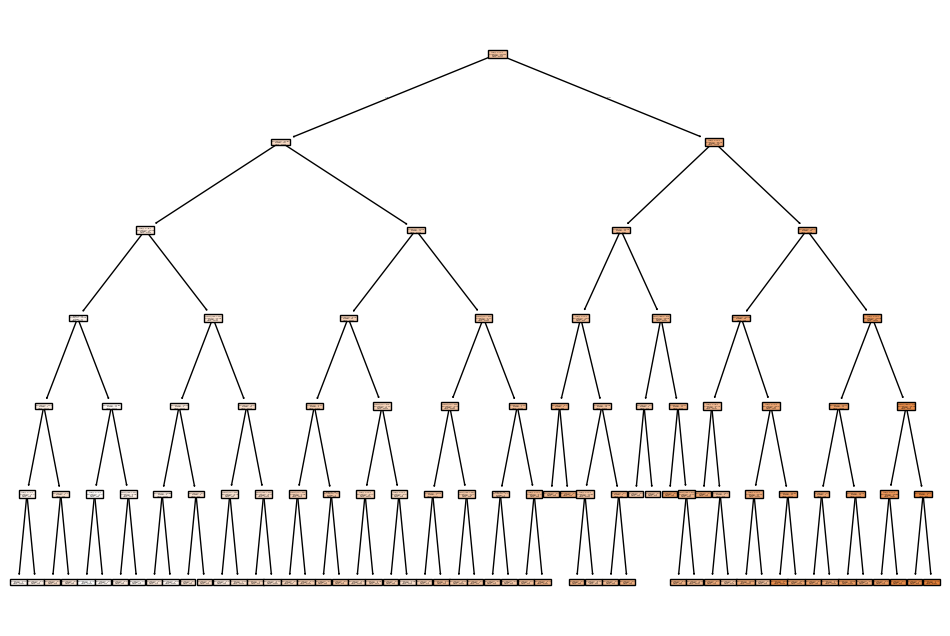

In [177]:
plt.figure(figsize=(12,8))
plot_tree(
    tree_clf,
    feature_names=X.columns,
    filled=True
)
plt.show()

### 7. Modifica el max_depth a 3 y vuelve a entrenarlo

In [182]:
tree_clf_2 = DecisionTreeRegressor(max_depth=3, random_state=42)
tree_clf_2.fit(X_train, y_train)

pred_t_02 = tree_clf_2.predict(X_test)

### 8. Vuelve a evaluar tu modelo

In [183]:
print("MAE: ", mean_absolute_error(y_test, pred_t_02))
print("RMSE: ", root_mean_squared_error(y_test, pred_t_02))
print("MAPE: ", mean_absolute_percentage_error(y_test, pred_t_02))
print("R2: ", r2_score(y_test, pred_t))

MAE:  4.254308906350133
RMSE:  5.427601353380941
MAPE:  0.06491876934915675
R2:  0.7921058441287924


### 9. Vuelve a representar su árbol

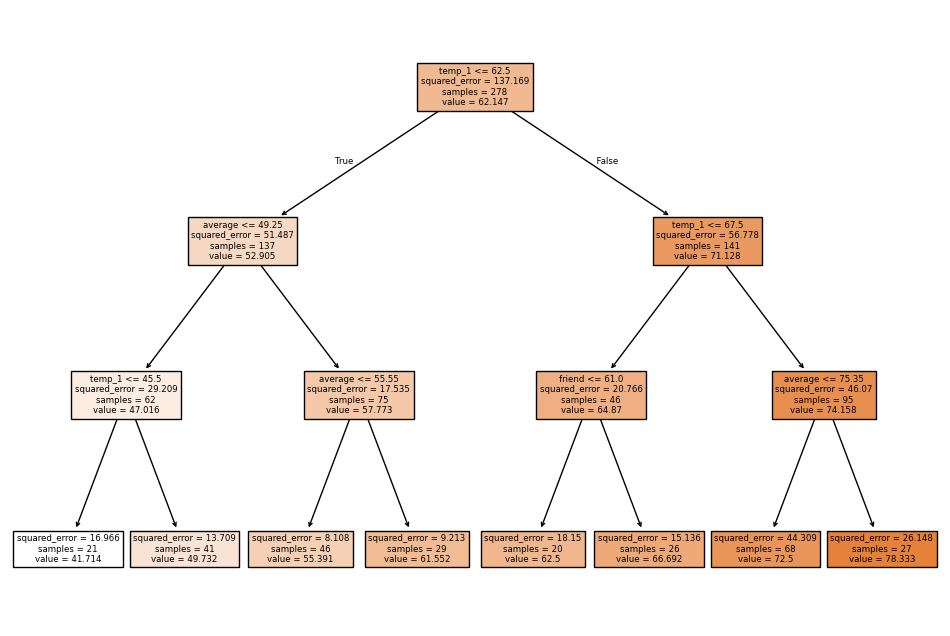

In [184]:
plt.figure(figsize=(12,8))
plot_tree(
    tree_clf_2,
    feature_names=X.columns,
    filled=True
)
plt.show()

### 10. Utiliza un grid search con cross validation para hiperparametrizar tu modelo

In [191]:
params = {"max_depth" : [2, 3, 4, 5, 6, 7, 8, 9, 10]}

gs = GridSearchCV(estimator=tree_clf_2, param_grid=params, cv=10, scoring='r2', verbose=3)
gs.fit(X_train, y_train)

print(gs.best_estimator_)
print(gs.best_score_)
print(gs.best_params_)



Fitting 10 folds for each of 9 candidates, totalling 90 fits
[CV 1/10] END ......................max_depth=2;, score=0.740 total time=   0.0s
[CV 2/10] END ......................max_depth=2;, score=0.723 total time=   0.0s
[CV 3/10] END ......................max_depth=2;, score=0.822 total time=   0.0s
[CV 4/10] END ......................max_depth=2;, score=0.693 total time=   0.0s
[CV 5/10] END ......................max_depth=2;, score=0.757 total time=   0.0s
[CV 6/10] END ......................max_depth=2;, score=0.771 total time=   0.0s
[CV 7/10] END ......................max_depth=2;, score=0.789 total time=   0.0s
[CV 8/10] END ......................max_depth=2;, score=0.691 total time=   0.0s
[CV 9/10] END ......................max_depth=2;, score=0.665 total time=   0.0s
[CV 10/10] END .....................max_depth=2;, score=0.648 total time=   0.0s
[CV 1/10] END ......................max_depth=3;, score=0.787 total time=   0.0s
[CV 2/10] END ......................max_depth=3;

In [193]:
tree_clf_2_best = gs.best_estimator_ 
tree_clf_2_best.fit(X_train, y_train)

predictions = tree_clf_2_best.predict(X_test)

print("MAE: ", mean_absolute_error(y_test, predictions))
print("RMSE: ", root_mean_squared_error(y_test, predictions))
print("MAPE: ", mean_absolute_percentage_error(y_test, predictions))
print("R2: ", r2_score(y_test, predictions))

MAE:  4.224485919361314
RMSE:  5.31521462345833
MAPE:  0.06496564811017988
R2:  0.8006262359754012


### 11. Obten el `feature_importances` de cada variable en el último modelo

In [194]:
variables_imp= tree_clf_2_best.feature_importances_
variables_imp

array([0.00284199, 0.00123749, 0.        , 0.81184101, 0.16884063,
       0.00427124, 0.00207424, 0.00291833, 0.00597507])

In [199]:
feat_imp = pd.DataFrame({'variable': X.columns,'importancia': variables_imp})
feat_imp

,variable,importancia
0,month,0.002842
1,day,0.001237
2,temp_2,0.000000
3,temp_1,0.811841
4,average,0.168841
5,forecast_noaa,0.004271
6,forecast_acc,0.002074
7,forecast_under,0.002918
8,friend,0.005975


<Axes: >

<Figure size 1000x600 with 0 Axes>

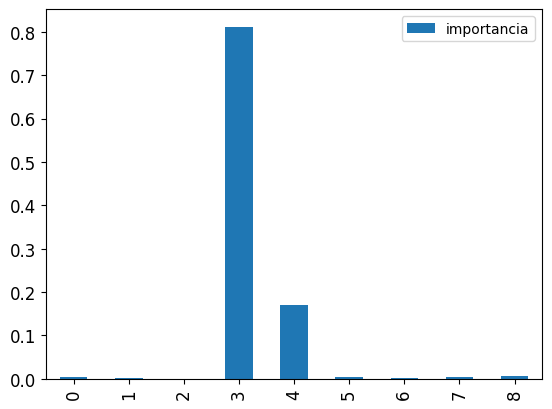

In [200]:
plt.figure(figsize=(10,6))
feat_imp.plot(kind='bar')


### 12. Construye un nuevo modelo `DecisionTreeClassifier` que te clasifique cuando en un día va a hacer una temperatura mayor a 15ºC. ¡Deberá tratarse como un problema de **clasificación**! Utiliza un grid search con cross validation y evalúa el mejor modelo.

In [ ]:
y_class = (df_seattle["actual"] > 15).astype(int)

In [ ]:
tree_clf = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_clf.fit(X_train, y_train)